In [1]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [2]:
animals = ['BS_40','BS_41','BS_42','BS_49','BS_50','BS_51','BS_56','BS_59','BS_67','BS_70','BS_72','BS_87','BS_108','DS_15','DS_19']

In [3]:
df = pd.read_csv('../../Source Data Files/Figure 2b.csv')

In [4]:
df

,Unnamed: 0,animal,session,cluster ID,exposure phase,FR modulation
0,0,TH_234,TH_234_4_passive_AC.pickle,26,3,2.696817
1,1,TH_234,TH_234_4_passive_AC.pickle,28,3,2.345059
2,2,TH_234,TH_234_4_passive_AC.pickle,30,3,0.892532
3,3,TH_234,TH_234_4_passive_AC.pickle,60,3,3.718593
4,4,TH_234,TH_234_4_passive_AC.pickle,63,3,1.643192
...,...,...,...,...,...,...
1535,1535,TH_201,TH_201_7_passive_AC.pickle,9,3,13.791349
1536,1536,TH_201,TH_201_7_passive_AC.pickle,10,3,2.763819
1537,1537,TH_201,TH_201_7_passive_AC.pickle,33,3,1.230425
1538,1538,TH_201,TH_201_7_passive_AC.pickle,38,3,4.891122


In [5]:
FRmod_preearly = []
FRmod_prelate = []
FRmod_preexpert = []
FRmod_postearly = []
FRmod_postlate = []
FRmod_postexpert = []

for row in df.iloc:
    if row['exposure phase'] == 1:
        FRmod_preearly.append(row['FR modulation'])
    if row['exposure phase'] == 2:
        FRmod_prelate.append(row['FR modulation'])
    if row['exposure phase'] == 3:
        FRmod_preexpert.append(row['FR modulation'])
        
    if row['exposure phase'] == 4:
        FRmod_postearly.append(row['FR modulation'])
    if row['exposure phase'] == 5:
        FRmod_postlate.append(row['FR modulation'])
    if row['exposure phase'] == 6:
        FRmod_postexpert.append(row['FR modulation'])

FRmod_preearly = np.array(FRmod_preearly)
FRmod_prelate = np.array(FRmod_prelate)
FRmod_preexpert = np.array(FRmod_preexpert)
FRmod_postearly = np.array(FRmod_postearly)
FRmod_postlate = np.array(FRmod_postlate)
FRmod_postexpert = np.array(FRmod_postexpert)

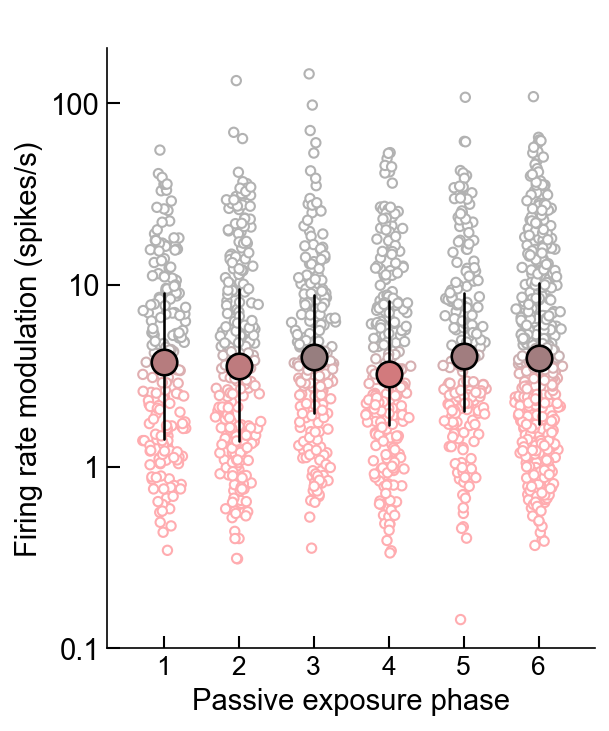

In [6]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

fig,ax = make_axis_size(3.25, 4, left=.3, bottom=.3, right=0, top=0)
switch_offset = 0

################################################################################################################

size = 20
summary_size=150
summary_width=1.25

mn = 3.5
spread = 2.5
    
###
    
FRmod_baseline_median = 3.5
data = [FRmod_preearly,FRmod_prelate,FRmod_preexpert,FRmod_postearly,FRmod_postlate,FRmod_postexpert]
labels = ['Early','Late','Expert','Early','Late','Expert']
numCon = len(data)

###

X = [np.ones(len(l))*idx + polarity*switch_offset for idx,(l,polarity) in enumerate(zip(data,[-1,-1,-1,1,1,1]))]
_,Y = ilep.violin(np.concatenate(X),np.concatenate(data),width=0.75,minjitter=0.075)
X,_ = ilep.violin(np.concatenate(X),np.log10(np.concatenate(data)),width=0.75,minjitter=0.075)
colors = NCR_CR_cmap( (Y-(mn-spread/2))/ (spread) )

ax.scatter(X, Y, s=size, ec=colors, fc='white', lw=1,zorder=-10,clip_on=False)
ax.set_yscale('log',subs=[])

#Plot summary
for idx,(column,polarity) in enumerate(zip(data,[-1,-1,-1,1,1,1])):
    try:
        column = ilep.rmnan(column)
        percentCR = np.nanmean(np.greater(column,FRmod_baseline_median))*100

        eye_color= NCR_CR_cmap((percentCR-40)/20)
        border_color = 'k'
        Q1, median, Q3 = (np.percentile(column, q) for q in [25, 50, 75])
        
        ax.scatter([idx+polarity*switch_offset], [median], ec=border_color,fc=eye_color, s=summary_size,lw=summary_width, zorder=10)
        ax.plot([idx+polarity*switch_offset, idx+polarity*switch_offset], [Q1, Q3], c=border_color, lw=summary_width, zorder=9, solid_capstyle='round')
    except:
        pass
    
ax.fill_between(ax.get_xlim(),[ax.get_ylim()[0]]*2,[ax.get_ylim()[1]*1.5]*2,color='white',alpha=0.4,zorder=-5,clip_on=False)

################################################################################################################
labels = [1,2,3,4,5,6]

ax.set_ylim([0.1,200])
ax.set_yticks([0.1,1,10,100])
ax.set_yticklabels(['0.1','1','10','100'])
ylab = ax.set_ylabel('Firing rate modulation (spikes/s)')

ax.set_xlim([-0.75-switch_offset,5.75+switch_offset])
ax.set_xticks([0-switch_offset,1-switch_offset,2-switch_offset,3+switch_offset,4+switch_offset,5+switch_offset])
ax.set_xticklabels(labels)
xlab = ax.set_xlabel('Passive exposure phase')

ax.tick_params(direction='in', length=6, width=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass

ttl = ax.set_title(' ')

artists = [ylab,xlab,ttl]
# fig.savefig(os.path.join('..','..','Figures','Figure 2b.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [7]:
data = SimpleNamespace()
data.preearly = FRmod_preearly
data.prelate = FRmod_prelate
data.preexpert = FRmod_preexpert
data.postearly = FRmod_postearly
data.postlate = FRmod_postlate
data.postexpert = FRmod_postexpert

ilep.mannwhitneycompareall(data)

pre-early   n = 198
pre-late    n = 241
pre-expert  n = 206
post-early  n = 244
post-late   n = 201
post-expert n = 450
pre-early  to pre-late   : 0.8841567607351049
pre-late   to pre-expert : 0.4690078676873415
pre-early  to pre-expert : 0.5555582202782947
post-early to post-late  : 0.4690078676873415
post-late  to post-expert: 0.8841567607351049
post-early to post-expert: 0.4690078676873415
